<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract + Introduction

The question is which pages an editor should check first when deciding where a content refresh may be needed across 30,000 pages. The dataset contains 30,000 pages from 32 clients using a 90-day window of data. I compared a Random Forest model with the existing rule-based baseline and used GroupKFold by client to test the models without mixing the same client's pages across folds. The Random Forest achieved a Precision@50 of 0.872 ± 0.069, compared with 0.788 ± 0.124 for the rule-based baseline. The result is intended to help rank pages for review and support an editor's decision, rather than automatically deciding which pages should be changed.


## 1. Question

*The research question and the decision it supports.*

The main problem I am trying to solve is deciding which pages should be checked first by a FlyRank editor. There are 30,000 pages in the dataset, so checking them all manually would take a lot of time. The current queue uses hand-written rules and flags. I wanted to test whether a model could put the pages that look more likely to be declining nearer to the top of the list.

Each row represents one page and contains data from the previous 90 days. The dataset has 32 pseudonymized clients. The model gives each page a score so that the pages can be ranked. An editor could then start with the first 50 pages and decide what to do with each one, such as refresh it, monitor it, expand it, or leave it as it is.

I used Precision@50 because an editor is unlikely to have time to check every page. I mainly wanted to know how many of the first 50 pages were actually labelled as declining. I also wanted to see how this compared with the current rule-based queue.

The current rules use fixed thresholds. This can sometimes cause a page to be flagged even when its other performance numbers look healthy.

One example in the data was a page in the `181+` freshness group with 61,678 impressions. The rules marked it as `HIGH_STALE_DECOY`. However, the page was ranking at position 1 and had a 15% CTR. So although the page was old and had a lot of impressions, its other numbers did not make it look like an obvious problem.

This example made me question whether the rules were always putting the most useful pages first. Age is still useful information, but I wanted to see what happened when it was considered together with other page signals.

The model is therefore being used to order the review queue. A high score means that the page should be looked at sooner. It does not mean that the page definitely needs a refresh.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:

#IMPORTS

import os
import json
import subprocess

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier

from IPython.display import SVG
from IPython.display import display

In [ ]:
# Step 1 — load the starter dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")

In [ ]:
# Step 2 —  Basic checks
print(df.columns)
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
print(df.shape, df["client_id"].nunique())
print(df["is_declining_label"].mean())

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')
(30000, 45) 32
0.5420666666666667


## Dataset and release

* **Release:** `content_refresh_anonymized.csv`
* The dataset contains 30,000 pages across 32 pseudonymized clients. The page-level measurements cover a trailing 90-day period. The original file has 44 columns. I added is_declining_label during preprocessing, which brings the working dataframe to 45 columns.

- I defined the target from trend_direction: a page is labelled 1 when trend_direction is "down". The resulting label rate is 0.542, so about 54.2% of the pages are labelled as declining.

- I did not use trend_direction or trend_pct as model features because they are directly related to the target. I also kept the existing baseline flags and score out of the model features. Those fields belong to the current rule-based system, and including them would make it harder to tell whether the model was adding anything beyond the existing rules.

- client_id is used only to create the grouped validation splits. It is not used as a prediction feature. Page IDs are also not used as predictors.

- The model therefore works from page-level performance and freshness signals rather than the existing decline label or the baseline's own scoring fields.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

I kept the model fairly small because I mainly wanted to test whether a few useful page signals could improve the existing review queue. I was not trying to build the most complicated model possible.

The label is `is_declining_label`. A page gets a value of 1 when `trend_direction` is `"down"`. I did not use `trend_direction` or `trend_pct` as model features because they are directly related to the target. Using them would give the model information that should not be available in a fair comparison.

The final feature list contains:

* `freshness_tier_enc` — the freshness group converted into an ordered number.
* `avg_position` — average search position.
* `ctr` — click-through rate.
* `impressions_90d` — impressions during the 90-day period.
* `avg_position_missing` — a flag for rows where `avg_position` is 0.

I also left `stale_flag`, `low_ctr_flag`, `is_decoy`, and `baseline_score` out of the model. These are part of the current rule-based system. If I used them as model inputs, the comparison would not be as useful because the model could just learn the existing rules.

For the baseline, I used the existing rule-based score. This lets me compare the current queue with the Random Forest using the same test folds.

I used 5-fold `GroupKFold` with `client_id` as the grouping variable. This keeps pages from the same client in one side of a fold instead of splitting that client's pages between training and testing. I used this because a normal random split would not be as suitable for the client structure in this dataset.

The main metric is Precision@50. I chose this because the intended use is a short editor queue. For each test fold, I ranked the pages and looked at the first 50. Precision@50 is the proportion of those 50 pages that were labelled as declining.

I also checked for leakage instead of only assuming that the feature list was clean. I first checked that the final features did not contain the banned label-related fields, the baseline fields, or overlapping-window fields.

For the actual leakage test, I deliberately added `trend_pct` and ran the same grouped cross-validation again. The normal feature set gave **0.872 ± 0.069** Precision@50. When `trend_pct` was added, the result increased to **1.000 ± 0.000**.

That result was a warning that `trend_pct` was giving the model information that was too closely connected to the target. I therefore removed it from the final model. I kept this test separate from the final results so that the reported Random Forest score does not include the leaked feature.



In [ ]:
#Initialize the feature encoding
tier_order = ["0-30", "31-90", "91-180", "181+"]

df["freshness_tier_enc"] = df["freshness_tier"].map(
    {tier: i for i, tier in enumerate(tier_order)}
)

In [ ]:
# flag missing position
df["avg_position_missing"] = (
    df["avg_position"] == 0
).astype(int)

In [ ]:
# baseline thresholds
STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

In [ ]:
# baseline flags
df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)

df["low_ctr_flag"] = (
    (df["avg_position"] <= 20)
    & (df["ctr"] < CTR_THRESHOLD)
    & (df["impressions_90d"] >= 500)
)

df["is_decoy"] = (
    (df["freshness_tier"] == "181+")
    & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)
)

In [ ]:
# calculate baseline score
def calculate_score(row):
    if row["is_decoy"]:
        return 3
    if row["stale_flag"] and row["low_ctr_flag"]:
        return 2
    if row["stale_flag"] or row["low_ctr_flag"]:
        return 1
    return 0

df["baseline_score"] = df.apply(
    calculate_score,
    axis=1
)

In [ ]:
# grouped validation
N_SPLITS = 5

gkf = GroupKFold(
    n_splits=N_SPLITS
)

In [ ]:
#Initialize Precision@50
def precision_at_k(
    sub_df,
    score_col,
    k=50,
    tiebreak_col="impressions_90d"
):
    ranked = sub_df.sort_values(
        [score_col, tiebreak_col],
        ascending=[False, False]
    )

    top_k = ranked.head(k)

    return top_k["is_declining_label"].mean()

In [ ]:
#Initialize your FINAL feature list
FEATURES = [
    "freshness_tier_enc",
    "avg_position",
    "ctr",
    "impressions_90d",
    "avg_position_missing"
]

In [ ]:
print("\nFinal features:")
print(FEATURES)


Final features:
['freshness_tier_enc', 'avg_position', 'ctr', 'impressions_90d', 'avg_position_missing']


In [ ]:
print("\nLabel counts:")
print(df["is_declining_label"].value_counts())


Label counts:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64


In [ ]:
print("\nBaseline score distribution:")
print(df["baseline_score"].value_counts().sort_index())


Baseline score distribution:
baseline_score
0    19915
1     9603
2      476
3        6
Name: count, dtype: int64


In [ ]:
print("\nGroupKFold check:")

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"]),
    start=1
):
    train_clients = set(df.iloc[train_idx]["client_id"])
    test_clients = set(df.iloc[test_idx]["client_id"])

    print(
        f"Fold {fold}: "
        f"train rows={len(train_idx)}, "
        f"test rows={len(test_idx)}, "
        f"train clients={len(train_clients)}, "
        f"test clients={len(test_clients)}, "
        f"overlap={len(train_clients & test_clients)}"
    )


GroupKFold check:
Fold 1: train rows=22992, test rows=7008, train clients=31, test clients=1, overlap=0
Fold 2: train rows=24269, test rows=5731, train clients=25, test clients=7, overlap=0
Fold 3: train rows=24247, test rows=5753, train clients=24, test clients=8, overlap=0
Fold 4: train rows=24245, test rows=5755, train clients=24, test clients=8, overlap=0
Fold 5: train rows=24247, test rows=5753, train clients=24, test clients=8, overlap=0


### Leakage Check

In [ ]:
def make_rf():
    return RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

In [ ]:
# check for leakage
# these columns should not be used in the model

# columns to exclude

BANNED = [
    "trend_direction",
    "trend_pct"
]

PRODUCT_FLAGS = [
    "stale_flag",
    "low_ctr_flag",
    "is_decoy",
    "baseline_score"
]

WINDOW_TERMS = [
    "last_30d",
    "prev_30d",
    "prev30"
]


In [ ]:
# label-related columns

banned_found = [
    col for col in FEATURES
    if col in BANNED
]


# baseline flags
product_flags_found = [
    col for col in FEATURES
    if col in PRODUCT_FLAGS
]


# overlapping time windows
window_features_found = [
    col for col in FEATURES
    if any(term in col for term in WINDOW_TERMS)
]



In [ ]:
# test leakage with trend_pct

# add trend_pct only for the leakage test
df["_leak_probe"] = df["trend_pct"]

LEAKY_FEATURES = FEATURES + ["_leak_probe"]

# use the same CV split
gkf = GroupKFold(n_splits=5)


# normal feature set
honest_p50s = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"])
):

    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    rf = make_rf()

    rf.fit(
        train_fold[FEATURES],
        train_fold["is_declining_label"]
    )

    test_fold["honest_score"] = rf.predict_proba(
        test_fold[FEATURES]
    )[:, 1]

    honest_p50s.append(
        precision_at_k(
            test_fold,
            "honest_score"
        )
    )

# add trend_pct and run it again
leak_p50s = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"])
):

    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    rf = make_rf()

    rf.fit(
        train_fold[LEAKY_FEATURES],
        train_fold["is_declining_label"]
    )

    test_fold["leak_score"] = rf.predict_proba(
        test_fold[LEAKY_FEATURES]
    )[:, 1]

    leak_p50s.append(
        precision_at_k(
            test_fold,
            "leak_score"
        )
    )




In [ ]:
# Print results
print(
    "Label-derived columns:",
    banned_found if banned_found else "CLEAN"
)
print(
    "Product/baseline flags:",
    product_flags_found if product_flags_found else "CLEAN"
)
print(
    "Overlapping-window features:",
    window_features_found if window_features_found else "CLEAN"
)

print("\nLeakage injection test")
print(
    f"Normal feature set:      "
    f"{np.mean(honest_p50s):.3f} ± {np.std(honest_p50s):.3f}"
)

print(
    f"With trend_pct injected: "
    f"{np.mean(leak_p50s):.3f} ± {np.std(leak_p50s):.3f}"
)

# remove the test column
df.drop(
    columns=["_leak_probe"],
    inplace=True
)

print("\nLeakage probe removed from dataframe.")

Label-derived columns: CLEAN
Product/baseline flags: CLEAN
Overlapping-window features: CLEAN

Leakage injection test
Normal feature set:      0.872 ± 0.069
With trend_pct injected: 1.000 ± 0.000

Leakage probe removed from dataframe.


I also tested whether the evaluation could catch target leakage instead of just assuming that the feature list was clean. I retrained the same Random Forest using the same 5-fold client-grouped split and Precision@50, but added `trend_pct` deliberately. The normal feature set scored **0.872 ± 0.069**, while the leakage version reached **1.000 ± 0.000**. That large jump shows that `trend_pct` gives the model information about the target in disguise, so including it would let the model cheat. I therefore kept it out of the final feature set; this test gives actual evidence for that decision rather than relying only on a column-name check.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
baseline_p50s = []
rf_p50s = []

gkf = GroupKFold(n_splits=5)

In [ ]:


for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"]),
    start=1
):
    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    # Baseline score
    baseline_p50 = precision_at_k(
        test_fold,
        "baseline_score"
    )

    baseline_p50s.append(baseline_p50)

    # Random Forest
    rf = make_rf()

    rf.fit(
        train_fold[FEATURES],
        train_fold["is_declining_label"]
    )

    test_fold["rf_score"] = rf.predict_proba(
        test_fold[FEATURES]
    )[:, 1]

    rf_p50 = precision_at_k(
        test_fold,
        "rf_score"
    )

    rf_p50s.append(rf_p50)

    print(
        f"Fold {fold}: "
        f"Baseline P@50={baseline_p50:.3f}, "
        f"RF P@50={rf_p50:.3f}"
    )

Fold 1: Baseline P@50=0.740, RF P@50=0.940
Fold 2: Baseline P@50=0.960, RF P@50=0.800
Fold 3: Baseline P@50=0.620, RF P@50=0.900
Fold 4: Baseline P@50=0.900, RF P@50=0.940
Fold 5: Baseline P@50=0.720, RF P@50=0.780


In [ ]:
fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Baseline P@50": baseline_p50s,
    "Random Forest P@50": rf_p50s
})
display(fold_results)

,Fold,Baseline P@50,Random Forest P@50
0,1,0.74,0.94
1,2,0.96,0.80
2,3,0.62,0.90
3,4,0.90,0.94
4,5,0.72,0.78


In [ ]:
# Overall results
baseline_p50 = np.mean(baseline_p50s)
baseline_p50_std = np.std(baseline_p50s)

model_p50 = np.mean(rf_p50s)
model_p50_std = np.std(rf_p50s)

base_rate = df["is_declining_label"].mean()

In [ ]:

print("\nOverall results")
print(
    f"Baseline P@50: "
    f"{baseline_p50:.3f} ± {baseline_p50_std:.3f}"
)

print(
    f"Random Forest P@50: "
    f"{model_p50:.3f} ± {model_p50_std:.3f}"
)

print(
    f"Base rate: "
    f"{base_rate:.3f}"
)


Overall results
Baseline P@50: 0.788 ± 0.124
Random Forest P@50: 0.872 ± 0.069
Base rate: 0.542


The Random Forest did better than the existing rule-based baseline across the five client-grouped test folds.

| Method              |      Precision@50 | What it means                                                |
| ------------------- | ----------------: | ------------------------------------------------------------ |
| Rule-based baseline | **0.788 ± 0.124** | Around 79% of the first 50 pages were labelled as declining. |
| Random Forest       | **0.872 ± 0.069** | Around 87% of the first 50 pages were labelled as declining. |
| Base rate           |         **0.542** | 54.2% of all pages were labelled as declining.               |

The Random Forest was about 8.4 percentage points higher than the baseline

The fold-level results were not identical. In Fold 2, the baseline actually did better than the Random Forest (**0.960 vs 0.800**). The model did better in the other four folds, which is why the overall average still favours the Random Forest.

The standard deviation was also lower for the Random Forest (**0.069 vs 0.124**). In this experiment, that means its top-50 precision varied less across the five client groups.

The base rate gives another useful comparison. Only 54.2% of all pages were labelled as declining, while the Random Forest's top 50 contained 87.2% declining pages on average.

Based on these results, I would use the Random Forest to help prioritise the editor queue. I would not interpret the 0.872 score as saying that every high-ranked page is a problem. The model is only helping select pages that are more likely to have the declining label. The editor still has to decide what should actually be done.


## 5. Limitations

*What this work cannot claim.*

There are several things I would be careful about claiming from this experiment.

First, the model is only being used to rank pages. It does not explain why a page declined. A high score also does not mean that one of the features caused the decline.

I only tested the model on this dataset and its 90-day window. I did not test it on another time period, so I do not know if the **0.872 Precision@50** would stay at the same level when search behaviour or client performance changes.

The choice of 50 pages also matters. I used Precision@50 because I was thinking about a small editor queue. If the editor wanted to review 100 or 200 pages instead, the results could be different.

There was also some difference between the client folds. The Random Forest did better overall, but in Fold 2 the baseline scored **0.960** compared with **0.800** for the Random Forest. So I would not assume that the model will always beat the rules for every client.

Another limitation is that the model does not make the final content decision. A page near the top still needs to be checked by an editor. The editor needs to decide whether the page actually has a problem and whether it should be refreshed, expanded, monitored, or left alone.

Because of these limitations, I would treat the Random Forest result as evidence that the ranking can be improved on this dataset, rather than proof that the model will always work better in production.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The main recommendation from this experiment is to use the Random Forest as a way of deciding where the editor starts.

### 1. Check the top of the ranking first

The first pages in the Random Forest ranking should be the starting point for the editor. These pages had the strongest scores from the features used by the model.

The editor should then check the actual page instead of assuming that it needs a refresh. Things like search performance, content quality, search intent, and outdated information still need to be checked manually.

### 2. Do not automatically refresh a high-ranked page

A high model score is a reason to look at a page sooner. It is not a reason to change the page automatically.

For example, if the editor checks a high-ranked page and finds that the content is still useful and matches the search intent, there may be no reason to make a change.

### 3. Continue down the queue after the highest-ranked pages

Pages lower in the ranking should not be treated as completely healthy. They are simply lower priority compared with the pages above them.

Once the highest-priority pages have been checked, the editor can continue through the rest of the queue using the same manual checks.

### How I would use the score

For this project, I would use the score to answer one question:

> Which pages should I look at first?

I would not use it to answer why a page declined or to automatically decide what action should be taken.

The final decision should stay with the editor. The model is mainly useful for reducing the number of pages the editor has to sort through before finding the ones worth checking.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



This section contains the figures and tables that support the results reported earlier. They are included here so that the evidence shown in the notebook matches the discussion in the paper.

In [ ]:
# Build the comparison table
comparison_table = pd.DataFrame({
    "Method": [
        "Rule-based baseline",
        "Random Forest",
        "Base rate"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50,
        base_rate
    ],
    "Std": [
        baseline_p50_std,
        model_p50_std,
        np.nan
    ]
})


In [ ]:

display( comparison_table)

,Method,Precision@50,Std
0,Rule-based baseline,0.788000,0.124322
1,Random Forest,0.872000,0.068819
2,Base rate,0.542067,NaN


In [ ]:
#display fold results table
fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Baseline P@50": baseline_p50s,
    "Random Forest P@50": rf_p50s
})



In [ ]:
display(fold_results)

,Fold,Baseline P@50,Random Forest P@50
0,1,0.74,0.94
1,2,0.96,0.80
2,3,0.62,0.90
3,4,0.90,0.94
4,5,0.72,0.78


In [ ]:
# locate charts
if os.path.isdir("flyrank-ml-internship-starter"):
    chart_dir = "flyrank-ml-internship-starter/outputs/charts"
else:
    chart_dir = "outputs/charts"

print("Chart directory:", chart_dir)

Chart directory: flyrank-ml-internship-starter/outputs/charts


In [ ]:
print(f"Found {len(os.listdir(chart_dir))} chart files")

Found 5 chart files


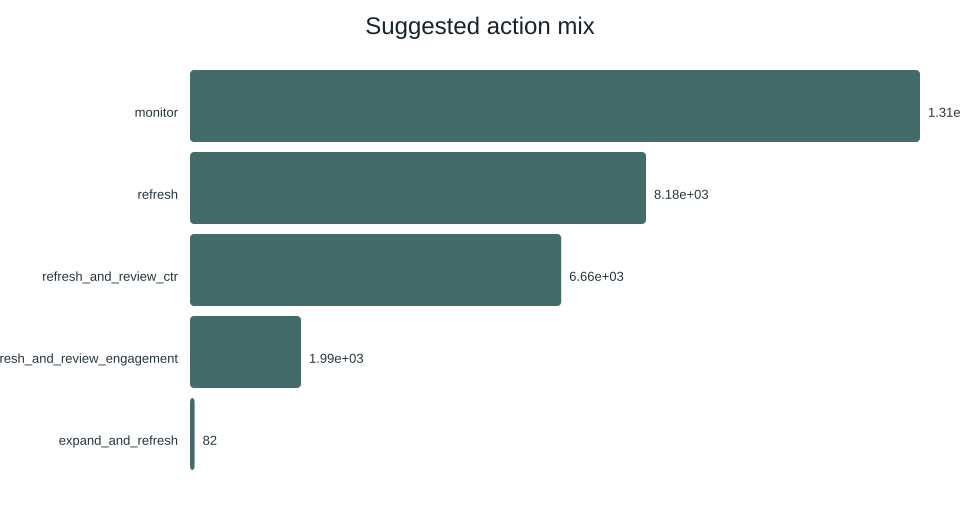

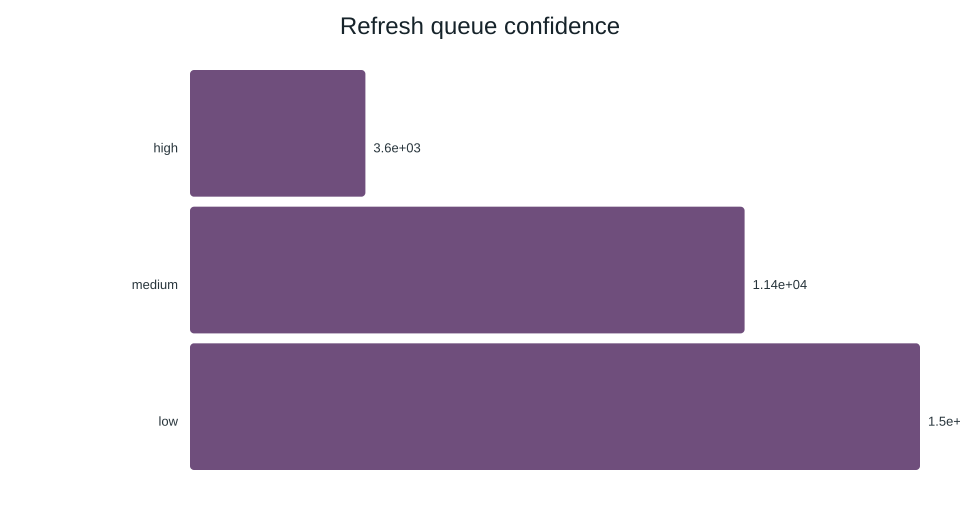

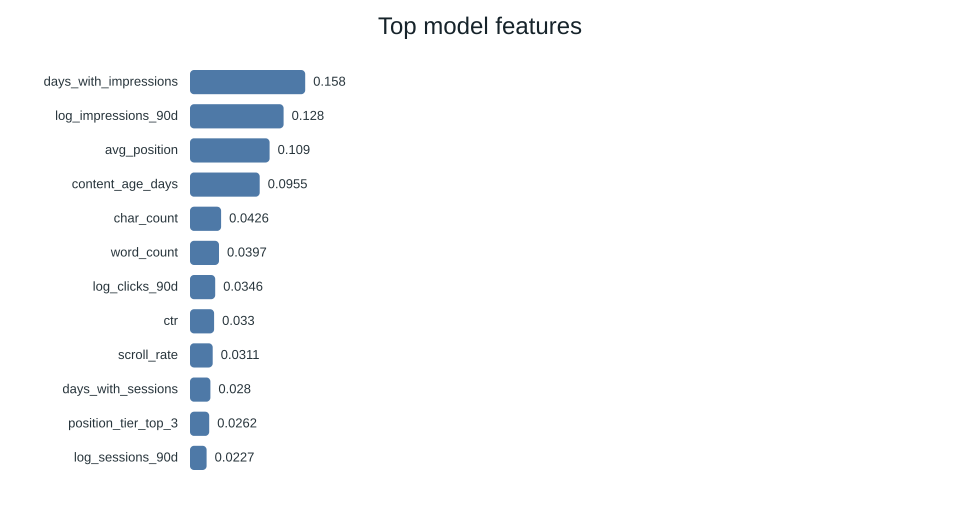

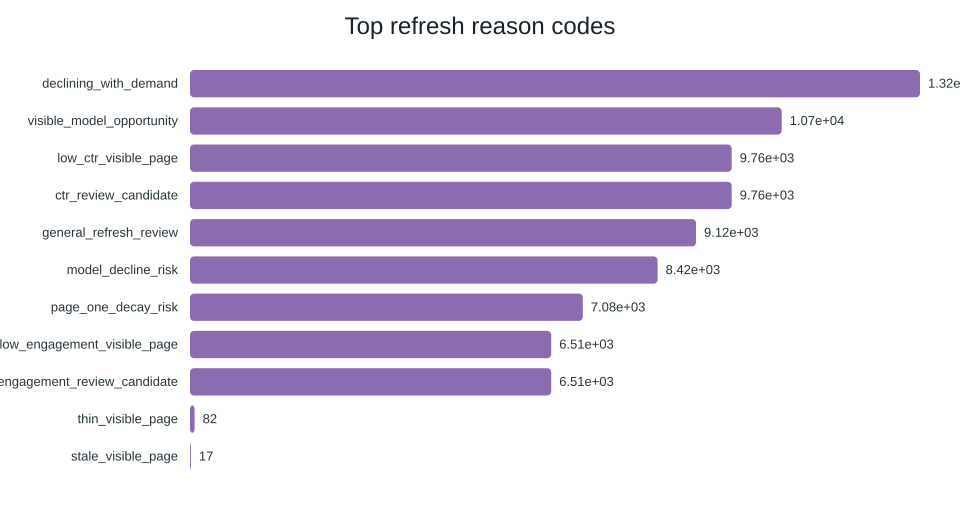

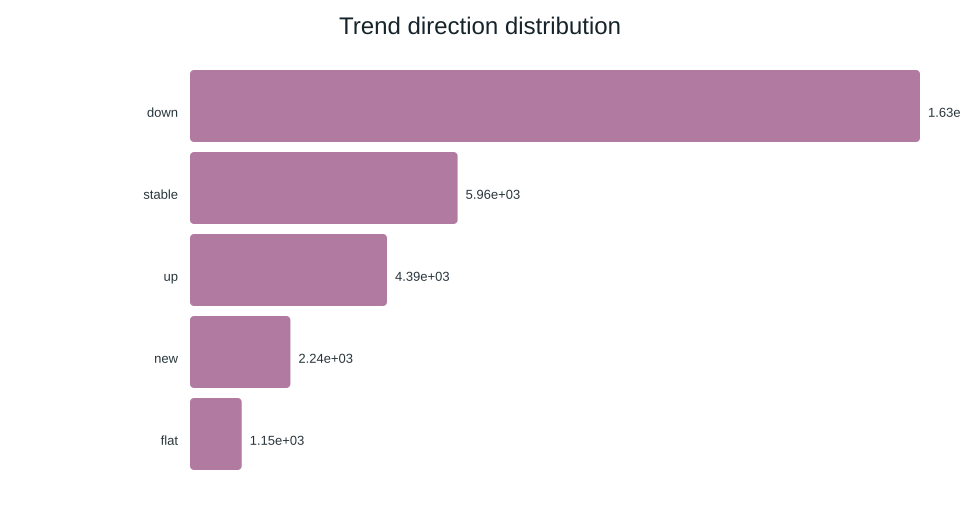

In [ ]:
display(SVG(os.path.join(chart_dir, "action_mix.svg")))
display(SVG(os.path.join(chart_dir, "confidence_mix.svg")))
display(SVG(os.path.join(chart_dir, "top_feature_importance.svg")))
display(SVG(os.path.join(chart_dir, "top_reason_codes.svg")))
display(SVG(os.path.join(chart_dir, "trend_distribution.svg")))

The tables below show the main evaluation results, including the fold-by-fold comparison between the baseline and Random Forest.

The charts show some additional views of the data and the model results. I included them so the results in the paper can be checked against the notebook outputs rather than relying only on the written explanation.

The main comparison is the baseline versus Random Forest Precision@50 under the same five client-grouped folds.

## 5-Minute Demo Outline

### Question

Which pages should an editor check first when deciding where a content refresh may be needed?

### Method

I used the anonymized FlyRank dataset and compared the existing rule-based baseline with a Random Forest model. I used GroupKFold by client so that pages from the same client were not split between training and validation folds. Precision@50 was the main metric because the goal was to rank the pages that should be reviewed first.

### One visual

The `fold_results` table shows the Precision@50 results across the validation folds, including the comparison between the rule-based baseline and the Random Forest. I would use this table to show how the model performed across different client-based folds rather than presenting a chart that I did not create.

### One honest result

The Random Forest achieved 0.872 ± 0.069 Precision@50, compared with 0.788 ± 0.124 for the rule-based baseline. This suggests that the model can improve the ranking of pages for review, but the result does not mean that every predicted page needs a content refresh.

### Recommendation

Use the model as a decision-support and prioritization tool for editors. The predictions should be checked against actual page performance and content context before making a refresh decision.


## Shareable Cuts  

### Social Media Post

I tested whether a simple ML model could help editors decide which pages to check first for a possible content refresh.

The Random Forest moved Precision@50 from 0.788 for the rule-based baseline to 0.872, using grouped validation by client. I compared the baseline with Random Forest using GroupKFold and used Precision@50 to focus on the pages ranked highest for review.

The full writeup and results are in my capstone paper: [add your deployed paper URL here]

### Employer Facing Summary

I built a content-refresh prioritization experiment using an anonymized FlyRank dataset containing 30,000 pages from 32 clients and a 90-day data window. I compared a rule-based baseline with a Random Forest model using GroupKFold by client and Precision@50 to evaluate how well pages could be ranked for review. The Random Forest achieved 0.872 ± 0.069 Precision@50 compared with 0.788 ± 0.124 for the baseline, showing that the model could support page-prioritization decisions while still requiring human review.


In [11]:
!jupyter nbconvert --to html /content/discoverey/work/notebooks/capstone.ipynb --output index.html

[NbConvertApp] Converting notebook /content/discoverey/work/notebooks/capstone.ipynb to html
/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 404847 bytes to /content/discoverey/work/notebooks/index.html


In [14]:
!git clone https://github.com/KinzaAsif2456/discoverey.git

fatal: destination path 'discoverey' already exists and is not an empty directory.


In [15]:
!ls /content/discoverey/work/notebooks/

capstone.ipynb			 w04_baseline_score.ipynb
index.html			 w04_signal_audit.ipynb
w01_research_question.ipynb	 w05_model.ipynb
w02_ml_task_framing.ipynb	 w06_validation_audit.ipynb
w03_data_contract.ipynb		 w07_action_playbook.ipynb
w03_feature_leakage_check.ipynb


In [12]:
!ls -la /content/discoverey/work/notebooks/index.html


-rw-r--r-- 1 root root 404981 Aug 16 19:30 /content/discoverey/work/notebooks/index.html


In [13]:
from google.colab import files
files.download('/content/discoverey/work/notebooks/index.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.